In [2]:
from importlib import reload
import os
import sys
# Set up paths for utility imports
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utils')

os.chdir(current_dir)
# Ensure the utilities directory is in the import path
if utilities_dir not in sys.path:
    sys.path.insert(0, utilities_dir)
    
import plotting
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import expon
from matplotlib.gridspec import GridSpec

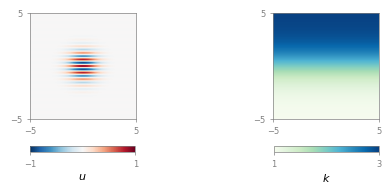

In [40]:

import sympy as sp

# -------------------------
# Variables
# -------------------------
x, y = sp.symbols("x y")
alpha = sp.symbols("alpha", positive=True)
beta = sp.symbols("beta", positive=True)
eps = sp.symbols("epsilon", positive=True)

# -------------------------
# Manufactured solution
# Infinite domain
# -------------------------
u = sp.exp(-alpha*(x**2+y**2))*sp.cos(beta*y)

k = 1 + 2/(1+sp.exp(-y/eps))

# -------------------------
# Poisson source term
# -------------------------
ux = sp.diff(u, x)
uy = sp.diff(u, y)

f = -(
    sp.diff(k*ux, x)
    +
    sp.diff(k*uy, y)
)

f = sp.simplify(f)

f

# -------------------------
# Parameters
# -------------------------
alpha = 0.5
beta = 10
epsilon = 1

# -------------------------
# Domain
# -------------------------
x = np.linspace(-5, 5, 300)
y = np.linspace(-5, 5, 300)

X, Y = np.meshgrid(x, y)

# -------------------------
# Analytical solution
# -------------------------
U = np.exp(-alpha*(X**2 + Y**2)) * np.cos(beta*Y)

# -------------------------
# Variable coefficient
# -------------------------
K = 1 + 2/(1 + np.exp(-Y/epsilon))

# -------------------------
# Plot style
# -------------------------
fig, ax = plt.subplots(
    1, 2,
    figsize=(6.0, 2.2),
)

# Left: u(x,y)
im1 = ax[0].imshow(
    U,
    extent=[x.min(), x.max(), y.min(), y.max()],
    origin="lower",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    aspect="equal",
    rasterized=True
)

ax[0].set_xticks([-5, 5])
ax[0].set_yticks([-5, 5])
ax[0].tick_params(axis="both", labelsize=6)
# for spine in ax[0].spines.values():
#     spine.set_linewidth(0.8)

# Right: k(y)
im2 = ax[1].imshow(
    K,
    extent=[x.min(), x.max(), y.min(), y.max()],
    origin="lower",
    cmap="GnBu",
    vmin=1,
    vmax=3,
    aspect="equal",
    rasterized=True
)

ax[1].set_xticks([-5, 5])
ax[1].set_yticks([-5, 5])
ax[1].tick_params(axis="both", labelsize=6)


# for spine in ax[1].spines.values():
#     spine.set_linewidth(0.1)

# -------------------------
# Colorbars (horizontal)
# -------------------------
cbar1 = fig.colorbar(
    im1,
    ax=ax[0],
    orientation="horizontal",
    fraction=0.038,
    pad=0.2,
)

cbar2 = fig.colorbar(
    im2,
    ax=ax[1],
    orientation="horizontal",
    fraction=0.038,
    pad=0.2
)

axis_color = "gray"

# Colorbar 1
cbar1.set_ticks([-1, 1])
cbar1.set_label("$u$", fontsize=8, labelpad=2, color='black')

cbar1.ax.tick_params(
    axis="x",
    labelsize=6,
    colors=axis_color,
    length=2,
    width=0.5
)

cbar1.outline.set_edgecolor(axis_color)
cbar1.outline.set_linewidth(0.5)


# Colorbar 2
cbar2.set_ticks([1, 3])
cbar2.set_label("$k$", fontsize=8, labelpad=2, color='black')

cbar2.ax.tick_params(
    axis="x",
    labelsize=6,
    colors=axis_color,
    length=2,
    width=0.5
)

cbar2.outline.set_edgecolor(axis_color)
cbar2.outline.set_linewidth(0.5)




for a in ax:
    # Tick locations
    a.set_xticks([-5, 5])
    a.set_yticks([-5, 5])

    # Tick marks and tick labels
    a.tick_params(
        axis="both",
        labelsize=6,
        colors=axis_color,
        length=2,
        width=0.5
    )

    # Axis lines (spines)
    for spine in a.spines.values():
        spine.set_color(axis_color)
        spine.set_linewidth(0.5)

plt.subplots_adjust(
    wspace=0.1,
    bottom=0.25
)
plt.savefig("figures/infinite_analytical_sol.svg", bbox_inches="tight", dpi=300)
plt.show()

os.makedirs("data", exist_ok=True)

# -------------------------
# Save analytical solution
# -------------------------
np.savez(
    "data/infinite_analytical_solution.npz",
    x=x,
    y=y,
    X=X,
    Y=Y,
    U=U,
    K=K,
    alpha=alpha,
    beta=beta,
    epsilon=epsilon,
)

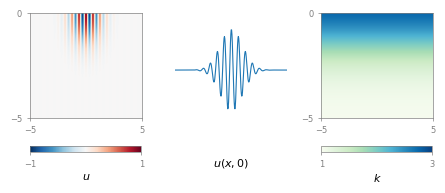

In [48]:
# -------------------------
# Parameters
# -------------------------
alpha = 0.5
beta = 10
epsilon = 0.75


# -------------------------
# Domain
# -------------------------
x = np.linspace(-5, 5, 300)
y = np.linspace(-5, 0, 300)

X, Y = np.meshgrid(x, y)


# -------------------------
# Analytical solution
# -------------------------
U = np.exp(-alpha*(X**2 + Y**2)) * np.cos(beta*X)


# -------------------------
# Boundary condition y=0
# -------------------------
u_boundary = np.exp(-alpha*x**2) * np.cos(beta*x)


# -------------------------
# Variable coefficient
# -------------------------
K = 1 + 2/(1 + np.exp(-(Y+1.5)/epsilon))


# -------------------------
# Figure
# -------------------------
fig, ax = plt.subplots(
    1, 3,
    figsize=(5.2, 2.2)
)


# =====================================================
# Solution u(x,y)
# =====================================================
im1 = ax[0].imshow(
    U,
    extent=[x.min(), x.max(), y.min(), y.max()],
    origin="lower",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    aspect="auto"
)

ax[0].set_xticks([-5, 5])
ax[0].set_yticks([-5, 0])
ax[0].tick_params(axis="both", labelsize=6)

for s in ax[0].spines.values():
    s.set_linewidth(0.8)


# =====================================================
# Boundary condition
# =====================================================
ax[1].plot(
    x,
    u_boundary+0.3,
    linewidth=0.8
)

ax[1].text(
    0.5, -0.08,
    r"$u(x,0)$",
    transform=ax[1].transAxes,
    ha="center",
    va="center",
    color="black",
    fontsize=8
)
ax[1].set_xlim(-5,5)
ax[1].set_ylim(-1.7,1.7)

ax[1].set_xticks([])
ax[1].set_yticks([])

for s in ax[1].spines.values():
    s.set_visible(False)


# =====================================================
# Coefficient k(y)
# =====================================================
im2 = ax[2].imshow(
    K,
    extent=[x.min(), x.max(), y.min(), y.max()],
    origin="lower",
    cmap="GnBu",
    vmin=1,
    vmax=3,
    aspect="auto"
)

 

ax[2].set_xticks([-5, 5])
ax[2].set_yticks([-5, 0])
ax[2].tick_params(axis="both", labelsize=6)

for s in ax[2].spines.values():
    s.set_linewidth(0.8)


 
# -------------------------
# Colorbars
# -------------------------
cbar1 = fig.colorbar(
    im1,
    ax=ax[0],
    orientation="horizontal",
    fraction=0.04,
    pad=0.2
)

cbar2 = fig.colorbar(
    im2,
    ax=ax[2],
    orientation="horizontal",
    fraction=0.04,
    pad=0.2
)

# Colorbar ticks
cbar1.set_ticks([-1, 1])
cbar2.set_ticks([1, 3])

# Colorbar styling
cbar1.ax.tick_params(
    axis="x",
    labelsize=6,
    colors=axis_color,
    length=2,
    width=0.5
)

cbar2.ax.tick_params(
    axis="x",
    labelsize=6,
    colors=axis_color,
    length=2,
    width=0.5
)

# Colorbar labels
cbar1.set_label(
    "$u$",
    fontsize=8,
    labelpad=2,
    color="black"
)

cbar2.set_label(
    "$k$",
    fontsize=8,
    labelpad=2,
    color="black"
)

# Colorbar outlines
cbar1.outline.set_edgecolor(axis_color)
cbar1.outline.set_linewidth(0.5)

cbar2.outline.set_edgecolor(axis_color)
cbar2.outline.set_linewidth(0.5)

# -------------------------
# Axis and colorbar style
# -------------------------
axis_color = "gray"

# =====================================================
# Main axes: u(x,y) and k(y)
# =====================================================
for a in [ax[0], ax[2]]:

    # Axis ticks
    a.tick_params(
        axis="both",
        labelsize=6,
        colors=axis_color,
        length=2,
        width=0.5
    )

    # Axis lines (spines)
    for spine in a.spines.values():
        spine.set_color(axis_color)
        spine.set_linewidth(0.5)


# Explicit ticks
ax[0].set_xticks([-5, 5])
ax[0].set_yticks([-5, 0])

ax[2].set_xticks([-5, 5])
ax[2].set_yticks([-5, 0])

# -------------------------
# Layout
# -------------------------
plt.subplots_adjust(
    wspace=0.3,
    bottom=0.25
)

plt.savefig("figures/semi_infinite_analytical_sol.svg", bbox_inches="tight", dpi=300)

plt.show()

# -------------------------
# Save analytical solution
# -------------------------
os.makedirs("data", exist_ok=True)

np.savez(
    "data/semi_infinite_analytical_solution.npz",
    x=x,
    y=y,
    X=X,
    Y=Y,
    U=U,
    K=K,
    u_boundary=u_boundary,
    alpha=alpha,
    beta=beta,
    epsilon=epsilon,
)